# Mô hình Thống kê và Học sâu — Dự báo PM2.5 (t + 24h)

Notebook này thực hiện huấn luyện và cấu hình các mô hình **ARIMA, SARIMA, ARIMAX, SARIMAX** và nhóm mô hình Deep Learning **(LSTM, GRU)** để có thông số đối chiếu với nhóm thuật toán Tree-based rừ notebook 7.

- **Đầu vào:** `train_dl.csv`, `val_dl.csv`, `test_dl.csv` đã được tiền xử lý, scaling, target được log hóa.
- **Đầu ra:** Các metric **RMSE, MAE, MAPE** (hoàn tác log về thang hiển thị µg/m³ để tính sai số).
- **Trực quan hóa**: Bảng tổng kết và biểu đồ Bar Chart so sánh thực tế và dự đoán.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELING = Path("../data/processed/modeling_fs")
TARGET_LOG = "target_pm25_h24_log"


In [2]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    # Do RMSE/MAE được đo bằng µg/m³, ta tiến hành hoàn tác các giá trị (inverse log)
    y_true_inv = np.expm1(y_true)
    y_pred_inv = np.expm1(y_pred)
    
    rmse = float(np.sqrt(mean_squared_error(y_true_inv, y_pred_inv)))
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    eps = 1e-6
    mask = np.abs(y_true_inv) > eps
    mape = np.mean(np.abs((y_true_inv[mask] - y_pred_inv[mask]) / y_true_inv[mask])) * 100.0
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

def load_xy(path: Path):
    df = pd.read_csv(path, parse_dates=["datetime_local"])
    feat = [c for c in df.columns if c not in ("datetime_local", TARGET_LOG)]
    return df[feat], df[TARGET_LOG], df["datetime_local"]

train_X, train_y, train_dt = load_xy(MODELING / "train_dl.csv")
val_X, val_y, val_dt = load_xy(MODELING / "val_dl.csv")
test_X, test_y, test_dt = load_xy(MODELING / "test_dl.csv")
print(train_X.shape, val_X.shape, test_X.shape)


(6383, 26) (2128, 26) (2128, 26)


## 1. Các mô hình Thống kê: ARIMA, SARIMA, ARIMAX, SARIMAX

Chúng ta sẽ chỉ định các tham số cơ bản (có thể tinh chỉnh qua auto_arima) để lấy baseline nhanh.
- Biến nội sinh (endog): `target_pm25_h24_log`
- Biến ngoại sinh (exog): Có thể chọn một số đặc trưng mạnh như weather, pm25 lag. Do thư viện sẽ chậm lại đáng kể nếu cho hết `train_X`, ta sẽ chọn top 5 đặc trưng.


In [3]:
# Lấy ra các biến ngoại sinh
# Chọn một số cột đại diện (có thể thay đổi tuỳ kết quả Feature Selection)
exog_cols = [c for c in train_X.columns if "pm25" not in c][:5] # Ví dụ lấy 5 đặc trưng thời tiết đầu tiên

train_exog = train_X[exog_cols].values
val_exog = val_X[exog_cols].values
test_exog = test_X[exog_cols].values

train_y_vals = train_y.values
val_y_vals = val_y.values
test_y_vals = test_y.values

stats_models = {}
stats_preds_train = {}
stats_preds_val = {}
stats_preds_test = {}


In [4]:
# Setup global sequences required by true out-of-sample mapping
all_y_global = np.concatenate([train_y_vals, val_y_vals, test_y_vals])
all_exog_global = np.vstack([train_exog, val_exog, test_exog])

val_start = len(train_y_vals)
val_end = val_start + len(val_y_vals)
test_start = val_end
test_end = test_start + len(test_y_vals)

# ── True 24-Step Walk-Forward Forecast (No Data Leakage) ──────────────────────
def rolling_forecast_24h(fitted_model, all_y, start_idx, end_idx, all_exog=None):
    init_end = start_idx - 24
    if all_exog is not None:
        current = fitted_model.apply(endog=all_y[:init_end], exog=all_exog[:init_end])
    else:
        current = fitted_model.apply(endog=all_y[:init_end])
        
    preds = []
    n = end_idx - start_idx
    for step, i in enumerate(range(start_idx, end_idx)):
        if all_exog is not None:
            exog_step = all_exog[i-24 : i-23]
            current = current.append([all_y[i-24]], exog=exog_step, refit=False)
            future_exog = np.tile(exog_step[0], (24, 1))
            fc = current.forecast(steps=24, exog=future_exog)
        else:
            current = current.append([all_y[i-24]], refit=False)
            fc = current.forecast(steps=24)
            
        val = float(fc.iloc[-1] if hasattr(fc, "iloc") else fc[-1])
        preds.append(val)
        if (step + 1) % 500 == 0:
            print(f"  rolling_forecast_24h: {step+1}/{n} done")
            
    return np.array(preds)

def fit_and_predict_stats(order, seasonal_order=None, use_exog=False, name="Model"):
    print(f"Training {name}...")
    exog_train = train_exog if use_exog else None
    
    model = ARIMA(endog=train_y_vals, exog=exog_train, order=order, seasonal_order=seasonal_order)
    model_fit = model.fit()
    
    stats_models[name] = model_fit
    stats_preds_train[name] = model_fit.fittedvalues
    
    stats_preds_val[name] = rolling_forecast_24h(
        model_fit, all_y_global, val_start, val_end, all_exog=all_exog_global if use_exog else None
    )
    
    stats_preds_test[name] = rolling_forecast_24h(
        model_fit, all_y_global, test_start, test_end, all_exog=all_exog_global if use_exog else None
    )
    print(f"{name} evaluation completed!")


In [5]:
# Chạy SARIMA: order=(1,1,1), seasonal=(1,1,1,24)
# (Tham số 24 là một ngày, có thể hạ bớt order để tránh over-complexity)
fit_and_predict_stats(order=(1, 0, 1), seasonal_order=(1, 0, 0, 24), use_exog=False, name="SARIMA")


Training SARIMA...


KeyboardInterrupt: 

In [ ]:
# Chạy ARIMAX: order=(1,1,1), dùng Exogenous variables
fit_and_predict_stats(order=(1, 1, 1), seasonal_order=(0, 0, 0, 0), use_exog=True, name="ARIMAX")


Training ARIMAX...


  rolling_forecast_24h: 500/2128 done


  rolling_forecast_24h: 1000/2128 done


  rolling_forecast_24h: 1500/2128 done


  rolling_forecast_24h: 2000/2128 done


  rolling_forecast_24h: 500/2128 done


  rolling_forecast_24h: 1000/2128 done


  rolling_forecast_24h: 1500/2128 done


  rolling_forecast_24h: 2000/2128 done


ARIMAX evaluation completed!


In [ ]:
# Chạy SARIMAX: order=(1,0,1), seasonal=(1,0,0,24), dùng Exogenous variables
fit_and_predict_stats(order=(1, 0, 1), seasonal_order=(1, 0, 0, 24), use_exog=True, name="SARIMAX")


Training SARIMAX...


  rolling_forecast_24h: 500/2128 done


  rolling_forecast_24h: 1000/2128 done


  rolling_forecast_24h: 1500/2128 done


  rolling_forecast_24h: 2000/2128 done


  rolling_forecast_24h: 500/2128 done


  rolling_forecast_24h: 1000/2128 done


  rolling_forecast_24h: 1500/2128 done


  rolling_forecast_24h: 2000/2128 done


SARIMAX evaluation completed!


## 2. Nhóm Mô hình Cạn & Học sâu: LSTM, GRU

Dữ liệu của ta có dạng feature matrix phẳng (chứa các độ trễ dưới dạng column). Ta sẽ reshape thành rank-3 `(batch, 1, num_features)` để chạy recurrent modules.

(Hoặc có thể build sequence generator đa bước, nhưng ta giữ chung form với tree-models)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def create_dataloaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=64):
    X_tr_t = torch.tensor(X_tr.values, dtype=torch.float32).unsqueeze(1) # (N, 1, features)
    y_tr_t = torch.tensor(y_tr.values, dtype=torch.float32).unsqueeze(1)
    
    X_v_t = torch.tensor(X_v.values, dtype=torch.float32).unsqueeze(1)
    y_v_t = torch.tensor(y_v.values, dtype=torch.float32).unsqueeze(1)
    
    X_te_t = torch.tensor(X_te.values, dtype=torch.float32).unsqueeze(1)
    y_te_t = torch.tensor(y_te.values, dtype=torch.float32).unsqueeze(1)
    
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=False)
    val_dl = DataLoader(TensorDataset(X_v_t, y_v_t), batch_size=batch_size, shuffle=False)
    test_dl = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=batch_size, shuffle=False)
    
    return train_dl, val_dl, test_dl, X_tr_t, X_v_t, X_te_t

train_loader, val_loader, test_loader, X_tr_t, X_v_t, X_te_t = create_dataloaders(train_X, train_y, val_X, val_y, test_X, test_y)
num_features = train_X.shape[1]


Device: cpu


In [ ]:
class SimpleRNNModel(nn.Module):
    def __init__(self, rnn_type="LSTM", input_size=10, hidden_size=64, num_layers=1):
        super(SimpleRNNModel, self).__init__()
        self.rnn_type = rnn_type
        if rnn_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        if self.rnn_type == "LSTM":
            out, _ = self.rnn(x)
        else:
            out, _ = self.rnn(x)
        out = out[:, -1, :] # Chỉ lấy step cuối
        out = self.fc(out)
        return out

def train_dl_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.to(device)
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_b.size(0)
            
        train_loss /= len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item() * X_b.size(0)
        val_loss /= len(val_loader.dataset)
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    return model

def predict_dl(model, X_tensor):
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor.to(device)).cpu().numpy().flatten()
    return preds


In [ ]:
# Huấn luyện LSTM
print("\n--- Training LSTM ---")
lstm_model = SimpleRNNModel(rnn_type="LSTM", input_size=num_features, hidden_size=64, num_layers=1)
train_dl_model(lstm_model, train_loader, val_loader, epochs=50, lr=0.001)

lstm_preds_train = predict_dl(lstm_model, X_tr_t)
lstm_preds_val = predict_dl(lstm_model, X_v_t)
lstm_preds_test = predict_dl(lstm_model, X_te_t)



--- Training LSTM ---


Epoch 10 | Train Loss: 0.1549 | Val Loss: 0.2219


Epoch 20 | Train Loss: 0.1321 | Val Loss: 0.2087


Epoch 30 | Train Loss: 0.1197 | Val Loss: 0.2004


Epoch 40 | Train Loss: 0.1105 | Val Loss: 0.1953


Epoch 50 | Train Loss: 0.1026 | Val Loss: 0.1964


In [ ]:
# Huấn luyện GRU
print("\n--- Training GRU ---")
gru_model = SimpleRNNModel(rnn_type="GRU", input_size=num_features, hidden_size=64, num_layers=1)
train_dl_model(gru_model, train_loader, val_loader, epochs=50, lr=0.001)

gru_preds_train = predict_dl(gru_model, X_tr_t)
gru_preds_val = predict_dl(gru_model, X_v_t)
gru_preds_test = predict_dl(gru_model, X_te_t)



--- Training GRU ---


Epoch 10 | Train Loss: 0.1502 | Val Loss: 0.2140


Epoch 20 | Train Loss: 0.1340 | Val Loss: 0.2082


Epoch 30 | Train Loss: 0.1246 | Val Loss: 0.2055


Epoch 40 | Train Loss: 0.1165 | Val Loss: 0.2015


Epoch 50 | Train Loss: 0.1100 | Val Loss: 0.1997


## 3. Tổng hợp Kết quả và Đánh giá

In [ ]:
metrics_list = []

# Đưa kết quả Stats models vào bảng
for name in stats_models.keys():
    metrics_list.append({"model": name, "split": "train", **regression_metrics(train_y_vals, stats_preds_train[name])})
    metrics_list.append({"model": name, "split": "val", **regression_metrics(val_y_vals, stats_preds_val[name])})
    metrics_list.append({"model": name, "split": "test", **regression_metrics(test_y_vals, stats_preds_test[name])})

# DL Models
for name, preds_tr, preds_v, preds_te in [
    ("LSTM", lstm_preds_train, lstm_preds_val, lstm_preds_test),
    ("GRU", gru_preds_train, gru_preds_val, gru_preds_test),
]:
    metrics_list.append({"model": name, "split": "train", **regression_metrics(train_y_vals, preds_tr)})
    metrics_list.append({"model": name, "split": "val", **regression_metrics(val_y_vals, preds_v)})
    metrics_list.append({"model": name, "split": "test", **regression_metrics(test_y_vals, preds_te)})

metrics_df = pd.DataFrame(metrics_list)
display(metrics_df)


,model,split,RMSE,MAE,MAPE
0,SARIMA,train,6.791861,4.460811,14.070653
1,SARIMA,val,14.825199,11.062652,49.201138
2,SARIMA,test,20.380042,13.748498,31.077024
3,ARIMAX,train,6.815867,4.097037,13.622503
4,ARIMAX,val,18.478093,13.324848,52.587084
5,ARIMAX,test,21.844108,14.621596,36.830007
6,SARIMAX,train,6.679447,4.329313,13.753764
7,SARIMAX,val,14.755193,10.735508,42.474244
8,SARIMAX,test,18.876625,13.488003,36.699342
9,LSTM,train,12.343638,8.271769,24.748783


In [ ]:
# Bảng metrics trên tập Test
test_metrics = metrics_df[metrics_df["split"] == "test"].set_index("model")[["RMSE", "MAE", "MAPE"]]
display(test_metrics.round(4))


,RMSE,MAE,MAPE
model,,,
SARIMA,20.3800,13.7485,31.0770
ARIMAX,21.8441,14.6216,36.8300
SARIMAX,18.8766,13.4880,36.6993
LSTM,18.6418,13.1048,33.6997
GRU,19.2400,13.4448,34.5523


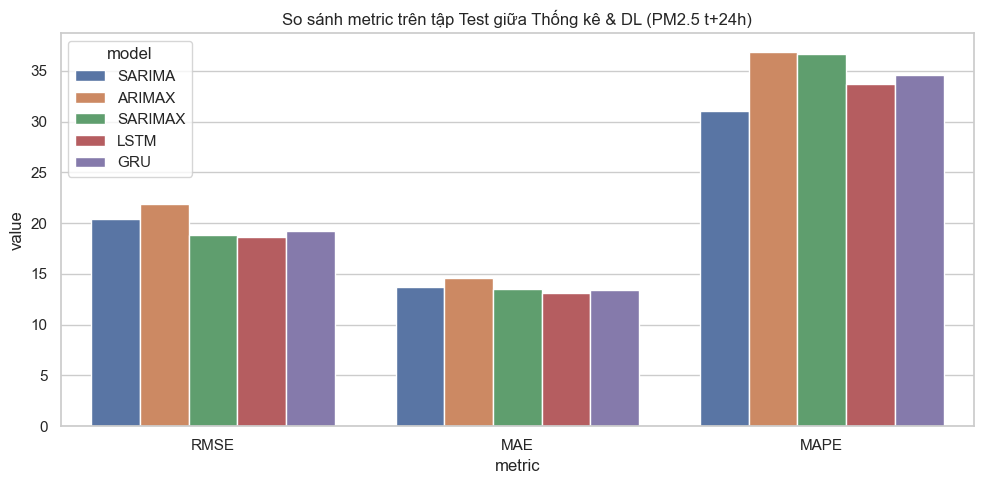

Đã lưu: C:\Users\User\Desktop\Matt Folder\Materials\MyUni\6th Semester\Business Data Analysis\Project\outputs\figures\stats_dl_models_test_metrics_bar.png


In [ ]:
# Biểu đồ cột so sánh
plot_df = metrics_df[metrics_df["split"] == "test"].melt(
    id_vars=["model"], value_vars=["RMSE", "MAE", "MAPE"], var_name="metric", value_name="value"
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x="metric", y="value", hue="model", ax=ax)
ax.set_title("So sánh metric trên tập Test giữa Thống kê & DL (PM2.5 t+24h)")
plt.tight_layout()
out_bar = FIG_DIR / "stats_dl_models_test_metrics_bar.png"
fig.savefig(out_bar, dpi=150)
plt.show()
print("Đã lưu:", out_bar.resolve())
